In [1]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [6]:
sgcc = SGCCircuit(param_bounds)

In [7]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_3_11_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [8]:
sgcc.load_saved_parameters(optimized_model['final_epoch_params'])

In [9]:
def mse(Y_pred, Y_true):
    ## The dimension of Y_true has to be expanded to broadcast across multiple samples
    return tf.reduce_mean((Y_pred - Y_true[None, :, :, :,])**2, axis = [1,2,3])

def compute_hessian(model, params, Y_true):

    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:
            Y_pred = model.predict(X)
            loss = mse(Y_pred, Y_true) 
        gradient = tape1.gradient(loss, params)
    hessians = []
    for g in gradient:
        hessians.append(tape2.jacobian(g, params))

In [10]:
def hessian_vector_product(model, X, Y_true, v):

    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:

            Y_pred = model.predict(X)
            loss = tf.reduce_mean((Y_pred - Y_true[None, :, :, :])**2)

        grads = tape1.gradient(loss, model.trainable_variables)

        # flatten dot product
        gv = tf.add_n([
            tf.reduce_sum(g * v_i)
            for g, v_i in zip(grads, v)
        ])

    Hv = tape2.gradient(gv, model.trainable_variables)
    return Hv

def random_vector_like(params):
    return [tf.random.normal(p.shape) for p in params]

In [11]:
v = random_vector_like(sgcc.trainable_variables)
Hv0 = hessian_vector_product(sgcc, X, Y_true, v)

## Clip amplitude centers to highpass:

In [12]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.2],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [13]:
dLGN_params = optimized_model['scaled_param_history']['dLGN_params'][:,-1]

In [14]:
model = SGCCircuit(param_bounds)
model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=1000)
model.update_transform()

In [15]:
dLGN_params[:,:,:,2,:,:] = model.dlgn_raw[:,:,:,2,:,:].numpy()

In [16]:
params = {
    'dLGN_params': dLGN_params,
    'V1_params': optimized_model['scaled_param_history']['V1_params'][:,-1]
}

In [17]:
# apply a jitter
p = {x[0]:x[1] + tf.random.uniform(x[1].shape, -0.75, 0.75) 
    for x in params.items()}

In [23]:
model = SGCCircuit(param_bounds)
model.load_saved_parameters(params)

In [24]:
# initialize the optimizer
optimizer = Optimize(model, epochs=2500, loss_threshold=0)

# fit the model
loss_decay = optimizer.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000001E61D2D6DC0>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.08185037970542908
med_loss = 0.2088932991027832
max_loss = 0.4491473138332367

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.07811242341995239
med_loss = 0.1860475391149521
max_loss = 0.42849037051200867

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.07679520547389984
med_loss = 0.17027190327644348
max_loss = 0.41358232498168945

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.07596369087696075
med_loss = 0.15865875780582428
max_loss = 0.4013083875179291

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.07458288222551346
med_loss = 0.14987629652023315
max_loss = 0.390529066324234

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.07366739958524704
med_loss = 0.14289987087249756
max_loss = 0.38044703006744385

Training step = 600, N_exploration_sampl

In [25]:
#v = random_vector_like(model.trainable_variables)
Hv1 = hessian_vector_product(model, X, Y_true, v)

In [26]:
norm_h0 = Hv0[0].numpy()/Hv0[0].numpy().max()
norm_h1 = Hv1[0].numpy()/Hv1[0].numpy().max()

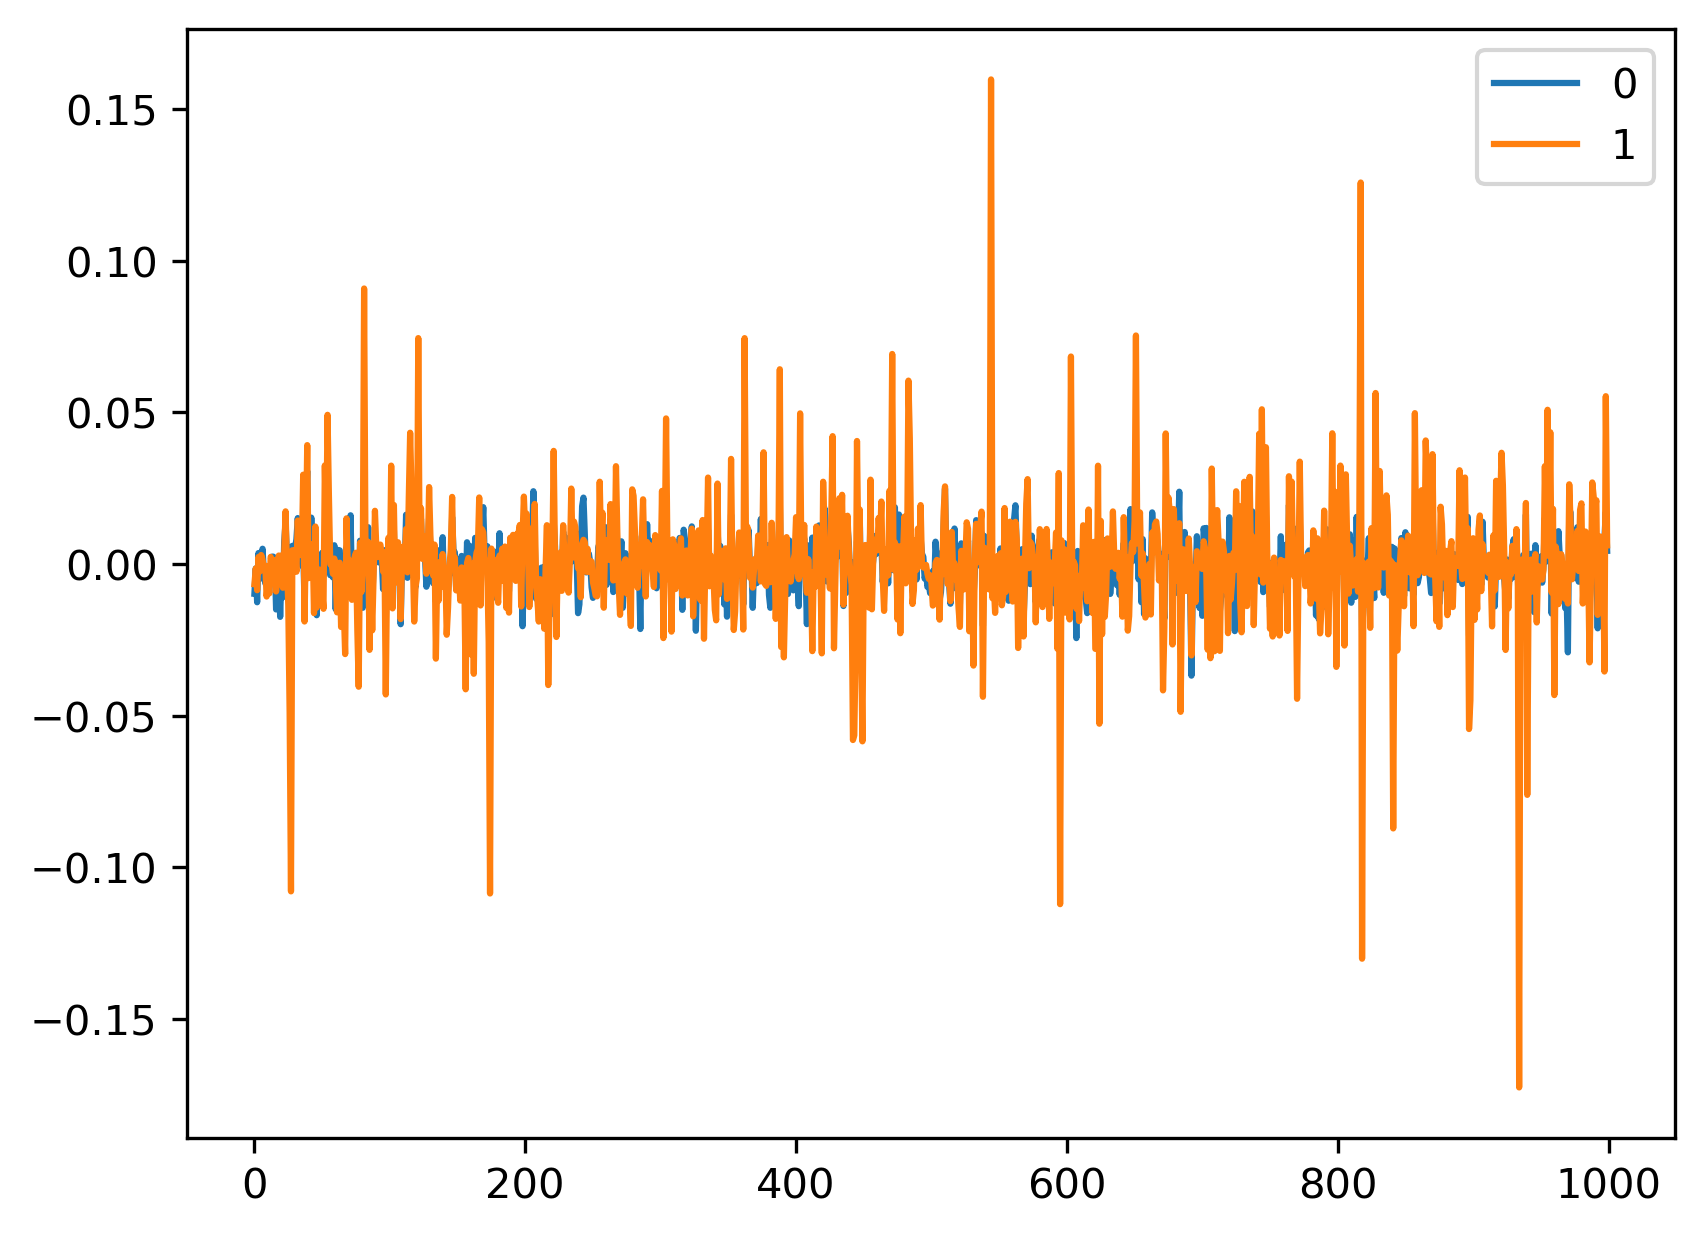

In [27]:
plt.plot(norm_h0[:,:,:,2,:,:].reshape(1000,-1).mean(1), label = '0')
plt.plot(norm_h1[:,:,:,2,:,:].reshape(1000,-1).mean(1), label = '1')
plt.legend()

In [ ]:
import tensorflow as tf
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh

# --------------------------------------------------------
# Step 0 — flatten helper functions
# --------------------------------------------------------
def flatten(params):
    """Flatten a list of tensors into a single vector."""
    return tf.concat([tf.reshape(p, [-1]) for p in params], axis=0)

def unflatten(flat_vector, params):
    """Reconstruct list of tensors from a flat vector using shapes of params."""
    v = []
    idx = 0
    for p in params:
        size = tf.size(p)
        v.append(tf.reshape(flat_vector[idx:idx+size], p.shape))
        idx += size
    return v

# --------------------------------------------------------
# Step 1 — Hessian-vector product
# --------------------------------------------------------
def hessian_vector_product(model, X, Y_true, v):
    """
    Compute H*v where H is Hessian of MSE loss wrt model parameters,
    and v is a list of tensors matching model.trainable_variables
    """
    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:
            Y_pred = model.predict(X)  # pure TF ops
            loss = tf.reduce_mean((Y_pred - Y_true[None, :, :, :])**2)
        grads = tape1.gradient(loss, model.trainable_variables)

        # compute dot product with vector v
        gv = tf.add_n([tf.reduce_sum(g * vi) for g, vi in zip(grads, v)])
    Hv = tape2.gradient(gv, model.trainable_variables)
    return Hv

# --------------------------------------------------------
# Step 2 — wrapper for LinearOperator
# --------------------------------------------------------
def make_hv_operator(model, X, Y_true):
    """
    Returns a function that maps a flat vector to Hessian-vector product (flat).
    """
    n_params = int(sum(tf.size(p) for p in model.trainable_variables))

    def mv(v_flat):
        v_tf = tf.convert_to_tensor(v_flat, dtype=tf.float32)
        v_struct = unflatten(v_tf, model.trainable_variables)
        Hv_struct = hessian_vector_product(model, X, Y_true, v_struct)
        return flatten(Hv_struct).numpy()

    return LinearOperator((n_params, n_params), matvec=mv, dtype=np.float32)

# --------------------------------------------------------
# Step 3 — compute eigenvalues
# --------------------------------------------------------
def compute_hessian_eigenvalues(model, X, Y_true, k=10, which='SM'):
    """
    Compute the smallest k eigenvalues of the Hessian of MSE loss
    using Hessian-vector products.
    """
    H_op = make_hv_operator(model, X, Y_true)
    eigvals, eigvecs = eigsh(H_op, k=k, which=which)
    return eigvals, eigvecs

# --------------------------------------------------------
# Step 4 — Example usage
# --------------------------------------------------------
# Assume:
#   sgcc = your trained SGCCircuit model
#   X = input array for final epoch
#   Y_true = target array for final epoch

# Compute 10 smallest eigenvalues
eigvals, eigvecs = compute_hessian_eigenvalues(sgcc, X, Y_true, k=10, which='SM')

print("Smallest eigenvalues of Hessian:")
print(eigvals)

# Identify degenerate directions (example threshold)
degenerate = eigvals / np.max(np.abs(eigvals)) < 1e-6
print(f"Number of degenerate directions: {degenerate.sum()}")